In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'/Users/kenyaharvey/Desktop/retail-sales-eda-project'

In [4]:
import os

os.listdir("data")

['retail_sales_dataset.csv']

In [5]:
df = pd.read_csv("data/retail_sales_dataset.csv")

In [6]:
os.listdir("data")

['retail_sales_dataset.csv']

In [7]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/23,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/23,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/23,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/23,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/23,CUST005,Male,30,Beauty,2,50,100


In [8]:
df.shape

(1000, 9)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Initial Dataset Inspection

The retail sales dataset contains 1,000 transaction records and 9 features related to customer demographics, product information, and sales performance.

The dataset includes customer details such as age and gender, product categories, purchase quantity, pricing information, and total transaction amounts.

A data quality check was performed:
- All columns contain complete data with no missing values.
- Numerical columns are correctly identified as integer values.
- Date values will be converted into datetime format for time series analysis.

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

/var/folders/ql/lmx1cprj1l1cjx478ft3c9840000gn/T/ipykernel_11699/936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [14]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [15]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [16]:
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [17]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [18]:
df["Month"] = df["Date"].dt.to_period("M")

In [19]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

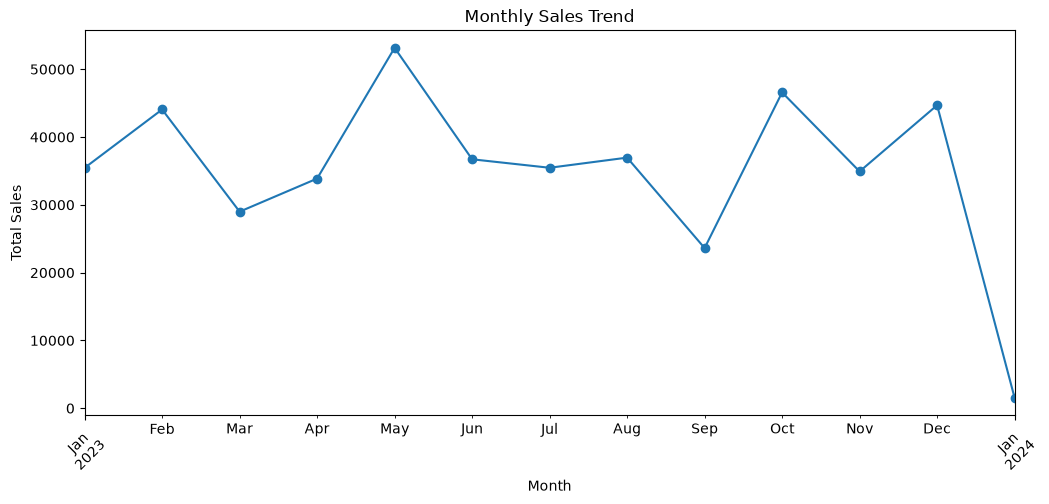

In [42]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("images/monthly_sales_trend.png", bbox_inches="tight")

plt.show()

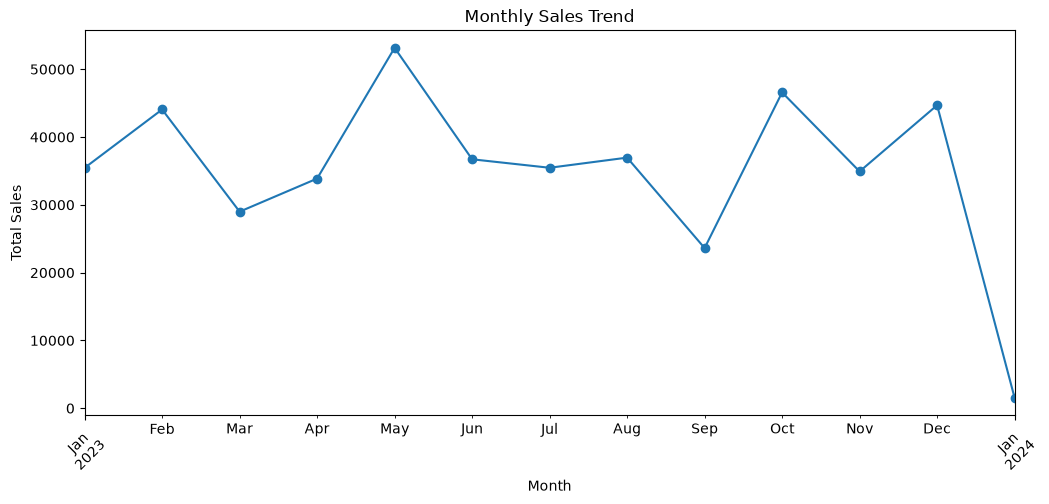

In [22]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

## Monthly Sales Trend Observation

The monthly sales trend shows how revenue changes throughout the year. Identifying high and low sales periods helps businesses understand seasonal purchasing patterns and make better decisions about inventory planning, promotions, and marketing strategies.

In [23]:
df["Quarter"] = df["Date"].dt.to_period("Q")

In [24]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

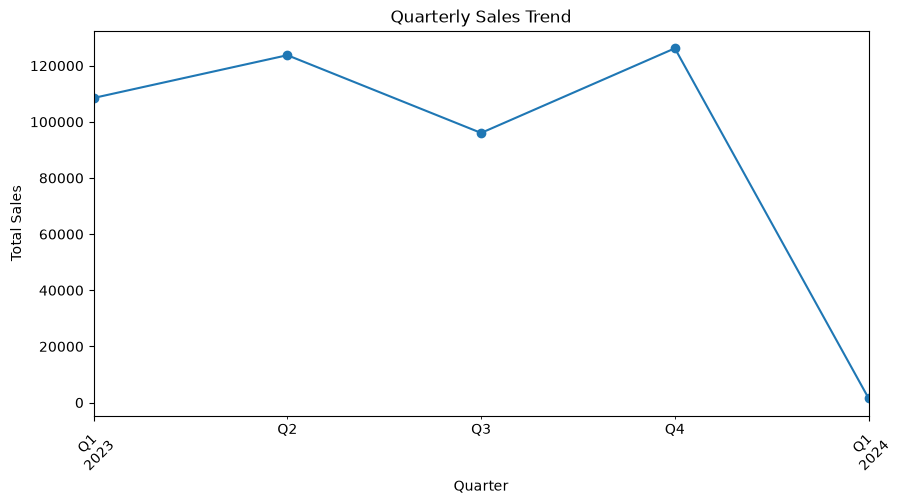

In [43]:
plt.figure(figsize=(10,5))

quarterly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("images/quarterly_sales_trend.png", bbox_inches="tight")

plt.show()

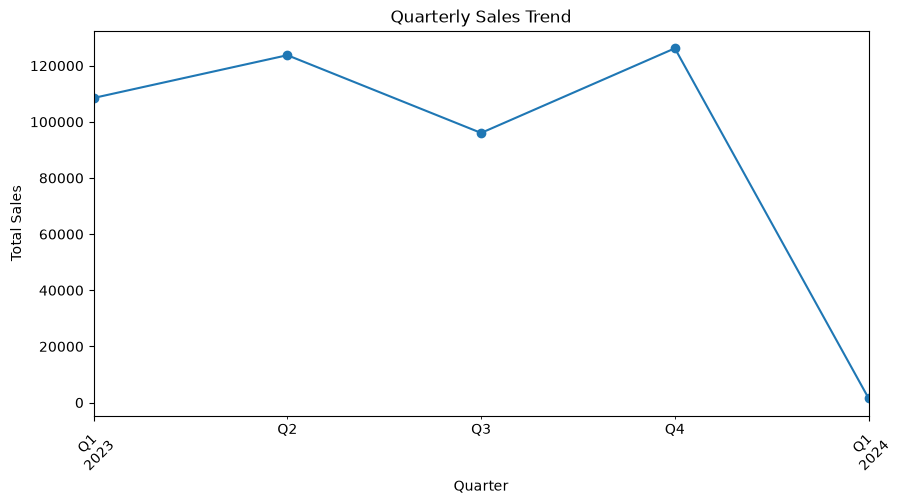

In [25]:
plt.figure(figsize=(10,5))

quarterly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

## Quarterly Sales Trend Observation

The quarterly sales analysis highlights broader revenue patterns across the year. Comparing quarters helps identify strong-performing periods and supports strategic decisions related to budgeting, promotions, and resource allocation.

In [26]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young Adult", "Adult", "Middle Age", "Senior"]
)

df["Age Group"].value_counts()

Age Group
Middle Age     441
Adult          297
Young Adult    169
Senior          93
Name: count, dtype: int64

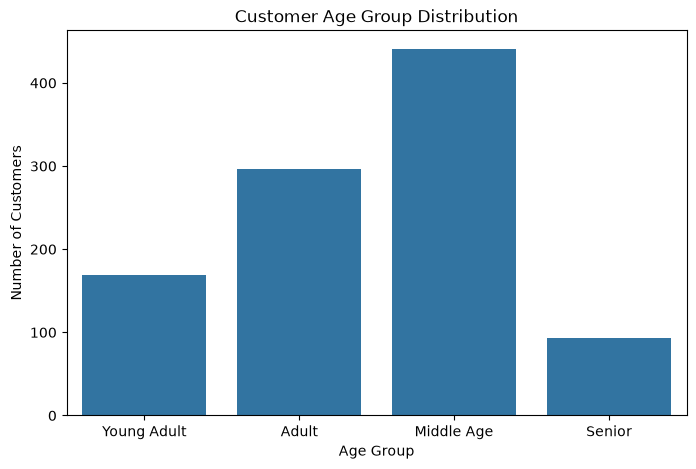

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age Group"
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.savefig("images/age_group_distribution.png", bbox_inches="tight")

plt.show()

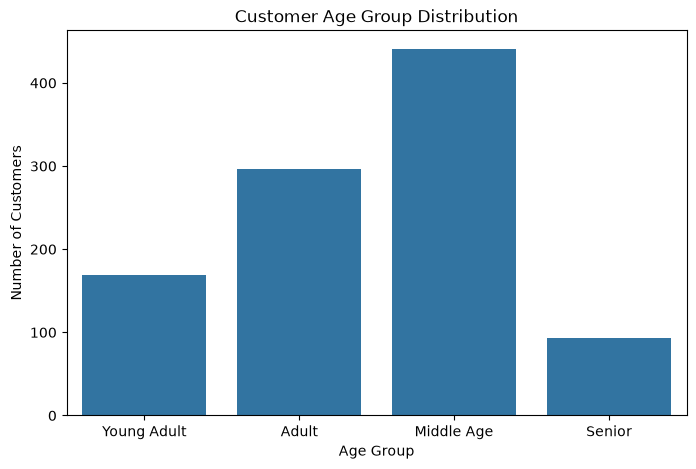

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age Group"
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

## Customer Age Group Observation

The age group distribution shows which customer segments make up the largest portion of sales transactions. Understanding customer demographics helps businesses create targeted marketing campaigns and improve customer engagement strategies.

In [28]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

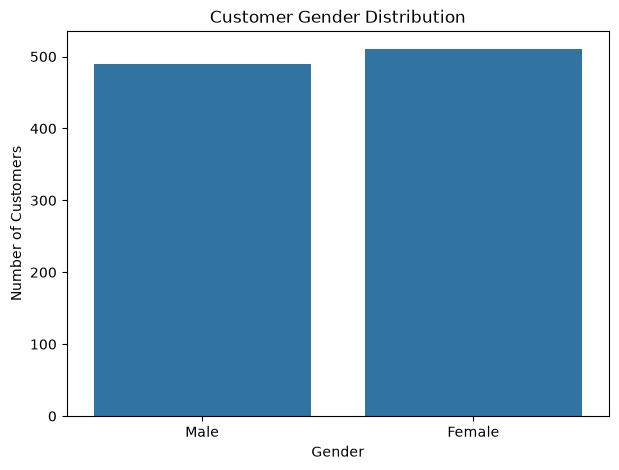

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.savefig("images/gender_distribution.png", bbox_inches="tight")

plt.show()

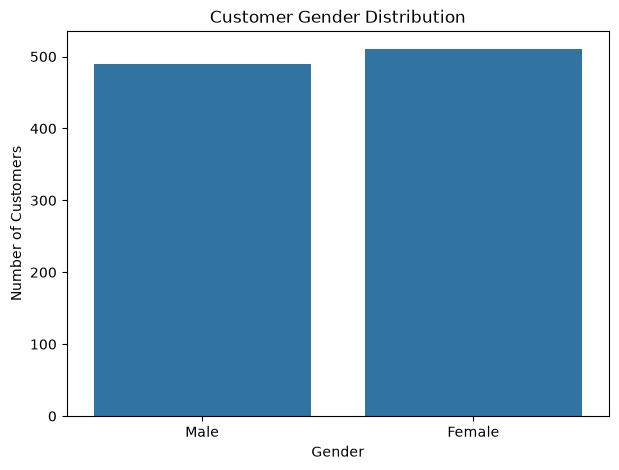

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Gender Distribution Observation

The gender breakdown provides insight into the customer base composition. Businesses can use this information to evaluate whether marketing strategies are reaching different customer groups effectively.

In [30]:
top_categories = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

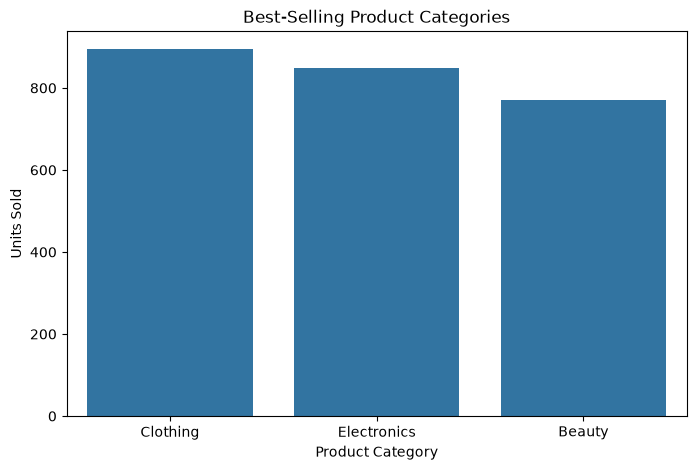

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_categories.index,
    y=top_categories.values
)

plt.title("Best-Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")

plt.savefig("images/product_category_sales.png", bbox_inches="tight")

plt.show()

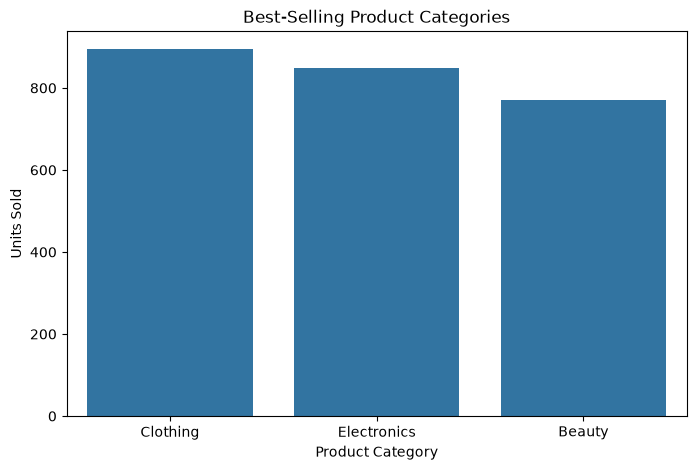

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_categories.index,
    y=top_categories.values
)

plt.title("Best-Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")

plt.show()

## Best-Selling Product Category Observation

The analysis identifies which product categories have the highest sales volume. These categories represent products with strong customer demand and can help guide inventory planning and promotional strategies.

In [32]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

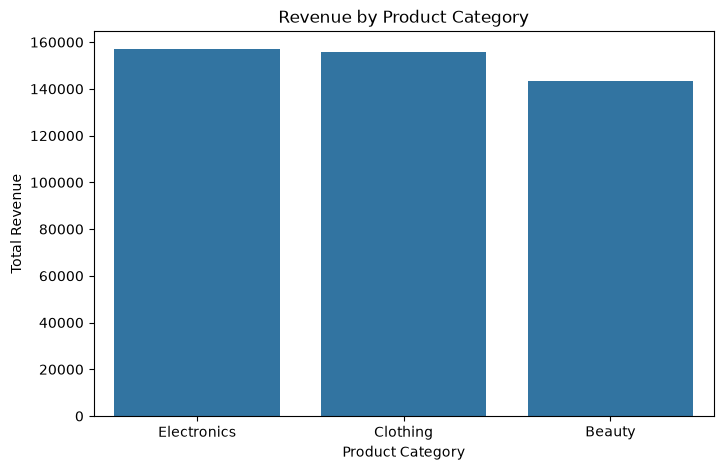

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.savefig("images/revenue_by_category.png", bbox_inches="tight")

plt.show()

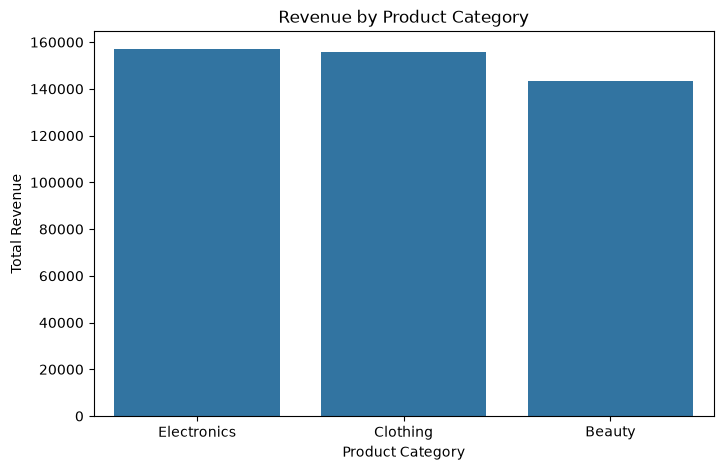

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

## Revenue by Product Category Observation

Revenue analysis shows which categories contribute the most financial value. Businesses can use this information to prioritize high-performing categories, optimize inventory, and develop targeted sales strategies.

In [34]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


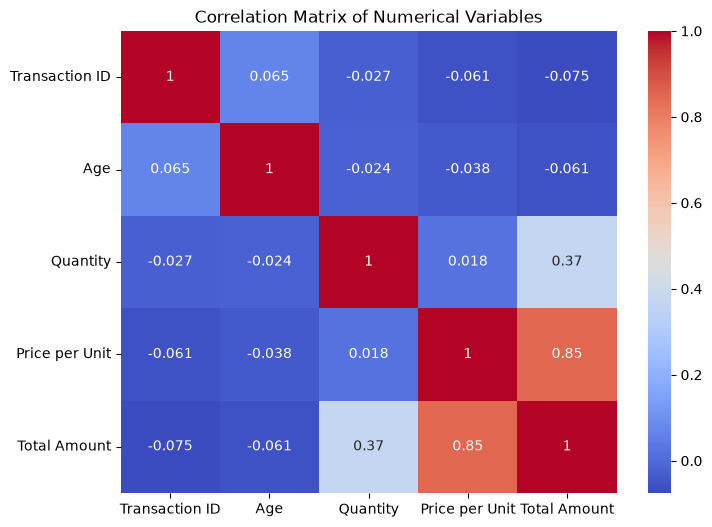

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")

plt.show()

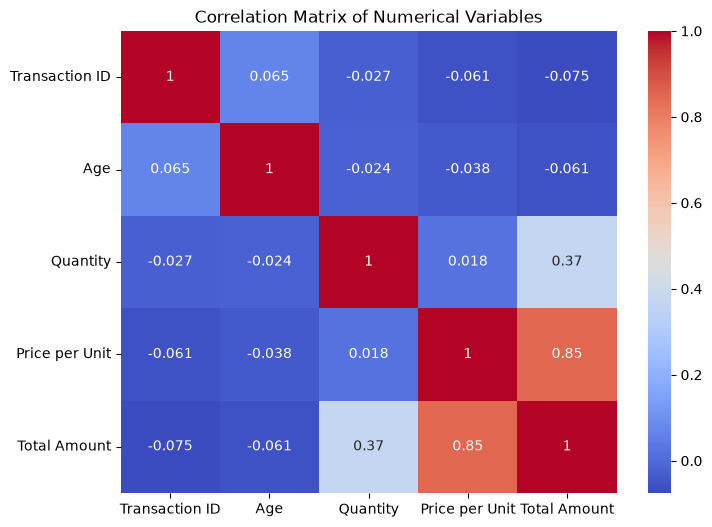

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

## Correlation Heatmap Observation

The correlation matrix shows relationships between numerical variables in the dataset.

Total Amount is expected to have a strong positive relationship with Quantity and Price per Unit because larger purchases and higher-priced products directly increase transaction value.

Understanding these relationships helps businesses identify factors that influence revenue and customer purchasing behavior.

In [36]:
avg_spending_age = (
    df.groupby("Age Group")["Total Amount"]
    .mean()
)

avg_spending_age

Age Group
Young Adult    500.295858
Adult          486.010101
Middle Age     439.637188
Senior         357.258065
Name: Total Amount, dtype: float64

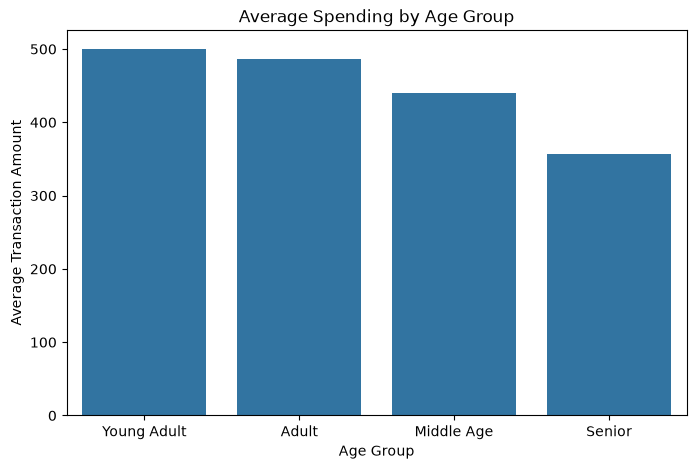

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_spending_age.index,
    y=avg_spending_age.values
)

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")

plt.savefig("images/average_spending_age_group.png", bbox_inches="tight")

plt.show()

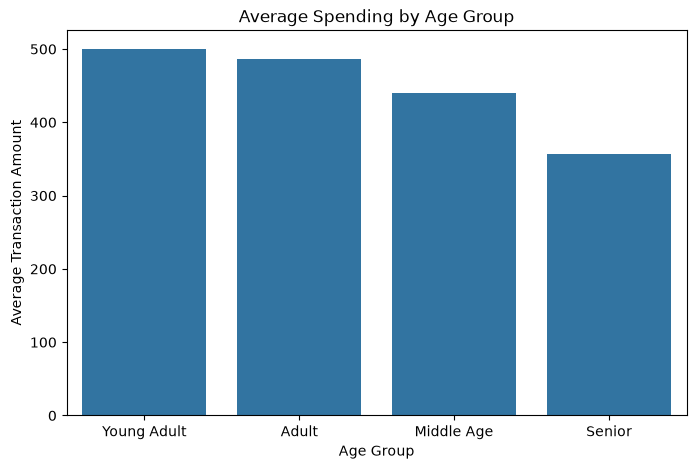

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_spending_age.index,
    y=avg_spending_age.values
)

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")

plt.show()

## Additional Visualization Observation

The average spending analysis reveals differences in purchasing behavior across age groups. This insight can help businesses design targeted promotions and personalize marketing strategies based on customer segments.

# Conclusion and Business Recommendations

Based on the exploratory data analysis, several business recommendations can be made:

### 1. Optimize Inventory Based on Product Demand
The best-selling product categories should receive priority in inventory planning to reduce stock shortages and ensure popular products remain available.

### 2. Create Targeted Marketing Campaigns
Customer demographic analysis shows differences in customer groups. Businesses can create targeted promotions based on age groups and gender preferences to improve customer engagement.

### 3. Use Seasonal Sales Trends for Planning
Monthly and quarterly sales patterns can help businesses plan promotions, staffing, and inventory levels during high-demand periods.

### 4. Focus on High-Revenue Categories
Product categories generating the most revenue should receive additional marketing attention and strategic investment to maximize profitability.